# Distributed Transfer Models: Fully-Connected, Star, and XY Routing --- Demo & Review Guide

This notebook demonstrates the distributed ISL transfer models in
`accelforge/model/_looptree/reuse/isl/distributed/distributed_buffers.py`:
`FullyConnectedMulticastModel`, `StarMulticastModel`, `XYRoutingMulticastModel`,
and the `EdgePressure` per-link load abstraction they share with the older
`HypercubeMulticastModel`. It is a companion to
`notebooks/astrasim2_correlation/correlation.ipynb` (same conventions: one-hot
GPU coordinates, `isl.Map.read_from_str`, `model.apply(0, Fill(...), Occupancy(...))`).

## What's new

- **`FullyConnectedMulticastModel`** --- 1 hop per fabric-crossing delivery,
  regardless of distance (the "flat full-mesh" view of a fully-connected fabric).
- **`StarMulticastModel`** --- the *spokes* realization of the same fabric
  (`src -> switch -> dst`); exposes per-spoke `EdgePressure` where
  `FullyConnectedMulticastModel` sees only a flat crossing count.
- **`XYRoutingMulticastModel`** --- dimension-order routing on a 2-D mesh, with
  a full per-directed-mesh-link `EdgePressure` decomposition.
- **`EdgePressure`** --- `{ edge -> #multicast-trees-crossing-it }`, with
  `.total()`, `.bottleneck()`, and `.eval_edge(name, coords)`, threaded through
  `TransferInfo.edge_pressure` (`accelforge/model/_looptree/reuse/isl/spatial.py`).
- The `fulfilled_fill` / `unfulfilled_fill` partition (`_covered_fills`) and the
  generic node-tuple lookup (`_mesh_node_tuple`) that every model above now
  shares, replacing ad hoc per-model logic.

## The two commits under review

The code this notebook exercises arrived across two commits on `rengz-correl`:

- **`142722f5`** --- *"LLM implemented code from pseudocode but it needs
  verification"*: introduces `EdgePressure`, `StarMulticastModel`, and the
  directed-mesh-link decomposition inside
  `XYRoutingMulticastModel._directed_mesh_links`.
- **`81be62a4`** --- *"isl distribuffers refactor"*: consolidates the
  `_eval_const` / `_const_pwq` / `_covered_fills` / `_mesh_node_tuple` helpers,
  fixes a `fulfilled_fill`/`unfulfilled_fill` bug (every fill used to be
  reported fulfilled unconditionally, even when no source held its datum), and
  threads `EdgePressure` through `TransferInfo.edge_pressure` so `hops` and the
  per-link decomposition come from one `identify_mesh_casts` call instead of
  two independently computed paths.

`HypercubeMulticastModel`, `identify_mesh_casts`, and `calculate_extents_per_dim`
predate both commits (they are the pre-existing, already-reviewed baseline) and
are not exercised here for that reason.

## How to use this notebook as a review guide

Each numbered section states which functions it exercises and cites their
current `file:line` ranges, recomputed against this working tree. Two passes
followed the two commits above: a documentation/comment style pass (comments
and docstrings only, verified AST-equivalent to `HEAD` with docstrings
stripped), and then a structural `/simplify` module split that moved
`EdgePressure` and its scalar-extraction helpers into `edge_pressure.py` and
`identify_mesh_casts` and its helpers into `mesh_casts.py`, leaving
`distributed_buffers.py` with a new `MulticastModel` base class (the shared
`__init__`/`apply` shape every model below now uses) and each model's own
cost kernel. Both passes are behavior-preserving -- verified against the
unmodified test suite and the asserted numbers below -- so the citations
reflect current file locations and line numbers, not the original commit
diffs. Every number asserted in a code cell below (`56`, `64`, `448`, ...) was
independently re-verified against this exact code before being written here.
Section 6 collects the section -> function -> file:line-range -> commit
mapping into one table so a reviewer can walk the diff systematically.


In [1]:
import islpy as isl
import pandas as pd
import matplotlib.pyplot as plt

from accelforge.model._looptree.reuse.isl.distributed.distributed_buffers import (
    FullyConnectedMulticastModel,
    StarMulticastModel,
    XYRoutingMulticastModel,
    _eval_const,
)
from accelforge.model._looptree.reuse.isl.mapping_to_isl.types import (
    Fill,
    Occupancy,
    SpatialTag,
)

CTX = isl.DEFAULT_CONTEXT


## 2. Fully-connected vs. star: 8-GPU one-hot all-to-all

GPU $i$ sits at one-hot coordinate $e_i$ of an 8-dimensional `noc` space (the
same encoding as `correlation.ipynb`). Two workloads distinguish the two models:

- **all-to-all (unicast)**: `data[s, d]` is a unique chunk from GPU $s$ to GPU
  $d$ --- every delivery has exactly one source and one destination.
- **broadcast**: GPU $g$ holds one private chunk `data[g]`, requested by every
  other GPU --- a genuine multicast (one producer, $N-1$ consumers, fan-out at
  the switch).

`FullyConnectedMulticastModel` costs every fabric-crossing delivery at 1 hop
regardless of the payload pattern, so **both** workloads give
$N(N-1) = 56$ hops. `StarMulticastModel` is the *spokes* realization of the
same fabric --- a delivery routes `src -> switch -> dst` --- and its per-spoke
`EdgePressure` **is** pattern-sensitive: only the broadcast pattern exposes the
switch's fan-out (egress load $1$, not $N-1$), because the all-to-all pattern
has no shared payload to fan out in the first place.

**Code exercised**: `MulticastModel.apply` (the shared `apply` every model
below now uses; `distributed_buffers.py:97-147`) together with
`FullyConnectedMulticastModel._transfer_cost`/`_cost_fully_connected`
(`distributed_buffers.py:265-284`, commit `81be62a4`); `StarMulticastModel`
(`distributed_buffers.py:523-599`, commit `142722f5`; its `hops`/
`edge_pressure` aggregation is now the shared `MulticastModel.apply` above,
fed by `StarMulticastModel._transfer_cost`, `distributed_buffers.py:546-547`);
`EdgePressure` (`edge_pressure.py:21-133`, commit `142722f5`, moved out of
`distributed_buffers.py` by the `/simplify` module split).


In [2]:
def onehot_constraints(prefix: str, n: int) -> str:
    """One-hot constraints over dims `{prefix}0..{prefix}{n-1}`. Reused from correlation.ipynb."""
    bounds = " and ".join(f"0 <= {prefix}{i} <= 1" for i in range(n))
    hot = " + ".join(f"{prefix}{i}" for i in range(n)) + " = 1"
    return f"{bounds} and {hot}"


def linear_id(prefix: str, n: int) -> str:
    """Affine recovery of the GPU id from a one-hot vector: id = sum i*g_i. Reused from correlation.ipynb."""
    return " + ".join(f"{i}*{prefix}{i}" for i in range(1, n))


def onehot_dist_fn(n: int) -> isl.Map:
    """Unit-cost distance function on the one-hot `noc` space: 0 hops if same
    GPU, 1 hop otherwise. Same shape as correlation.ipynb's `all_to_all_maps`.
    """
    xd = ", ".join(f"xd{i}" for i in range(n))
    xs = ", ".join(f"xs{i}" for i in range(n))
    same = " and ".join(f"xd{i} = xs{i}" for i in range(n))
    diff = " or ".join(f"(xd{i} < xs{i}) or (xd{i} > xs{i})" for i in range(n))
    return isl.Map.read_from_str(
        CTX,
        f"{{ [noc[{xd}] -> noc[{xs}]] -> hops[0] : {same}; "
        f"  [noc[{xd}] -> noc[{xs}]] -> hops[1] : {diff} }}",
    )


def all_to_all_maps(n: int) -> tuple[isl.Map, isl.Map, isl.Map]:
    """Build (occupancy, fill, dist_fn) for the N-GPU unicast all-to-all:
    data[s, d] is the unique chunk sent by GPU s to GPU d. Verbatim from
    notebooks/astrasim2_correlation/correlation.ipynb.
    """
    gs = ", ".join(f"gs{i}" for i in range(n))
    gd = ", ".join(f"gd{i}" for i in range(n))
    occ = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gs}] -> data[s, d] : {onehot_constraints('gs', n)} "
        f"and s = {linear_id('gs', n)} and 0 <= d < {n} }}",
    )
    fill = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gd}] -> data[s, d] : {onehot_constraints('gd', n)} "
        f"and d = {linear_id('gd', n)} and 0 <= s < {n} }}",
    )
    return occ, fill, onehot_dist_fn(n)


def broadcast_maps(n: int) -> tuple[isl.Map, isl.Map, isl.Map]:
    """Build (occupancy, fill, dist_fn) for the N-GPU one-hot *broadcast*
    pattern: GPU g holds one private chunk data[g], requested by every other
    GPU (one producer, N-1 consumers, fan-out at the switch). Same one-hot
    node encoding as `all_to_all_maps`, different fill/occ.
    """
    gs = ", ".join(f"gs{i}" for i in range(n))
    gd = ", ".join(f"gd{i}" for i in range(n))
    occ = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gs}] -> data[d] : {onehot_constraints('gs', n)} "
        f"and d = {linear_id('gs', n)} }}",
    )
    fill = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gd}] -> data[d] : {onehot_constraints('gd', n)} "
        f"and 0 <= d < {n} and d != {linear_id('gd', n)} }}",
    )
    return occ, fill, onehot_dist_fn(n)


N = 8
tags = [SpatialTag(i, 0) for i in range(N)]


In [3]:
# All-to-all (unicast) leg: reproduces correlation.ipynb's FullyConnectedMulticastModel
# result (56 hops = 8x7 fabric-crossing chunks) -- pattern-invariant, since FC only
# counts (dst, data) deliveries that cross the fabric, not whether a payload is shared.
occ_map, fill_map, dist_fn = all_to_all_maps(N)
fc_info = FullyConnectedMulticastModel(dist_fn).apply(
    0, Fill(tags, fill_map), Occupancy(tags, occ_map)
)
fc_hops = _eval_const(fc_info.hops)
assert fc_hops == N * (N - 1) == 56, fc_hops
print(f"FullyConnectedMulticastModel (all-to-all unicast): {fc_hops} hops")


FullyConnectedMulticastModel (all-to-all unicast): 56 hops


In [4]:
# Broadcast leg: each GPU's chunk is requested by every other GPU. This is what
# exposes StarMulticastModel's spoke asymmetry -- the switch fans a shared
# chunk out from a single egress -- which the unicast pattern above cannot show
# (there, every delivery is already a distinct chunk with no sharing to fan out).
def onehot_coords(g: int, n: int) -> list[int]:
    """One-hot coordinate vector for GPU `g` among `n` GPUs."""
    return [1 if i == g else 0 for i in range(n)]


occ_b, fill_b, dist_fn_b = broadcast_maps(N)
fill_bc = Fill(tags, fill_b)
occ_bc = Occupancy(tags, occ_b)

fc_info_b = FullyConnectedMulticastModel(dist_fn_b).apply(0, fill_bc, occ_bc)
fc_hops_b = _eval_const(fc_info_b.hops)
assert fc_hops_b == 56, fc_hops_b

star_info = StarMulticastModel(dist_fn_b).apply(0, fill_bc, occ_bc)
star_pressure = star_info.edge_pressure
star_hops = _eval_const(star_info.hops)

spoke_in = [star_pressure.eval_edge("spoke_in", onehot_coords(g, N)) for g in range(N)]
spoke_out = [star_pressure.eval_edge("spoke_out", onehot_coords(g, N)) for g in range(N)]

assert all(v == N - 1 for v in spoke_in), spoke_in
assert all(v == 1 for v in spoke_out), spoke_out
assert star_pressure.bottleneck() == N - 1 == 7
assert star_hops == N + N * (N - 1) == 64

total_ingress = sum(spoke_in)
assert total_ingress == fc_hops_b == 56, (total_ingress, fc_hops_b)

print(f"StarMulticastModel (broadcast): {star_hops} hops = {N} injections + {N * (N - 1)} deliveries")
print(f"  spoke_in per node : {spoke_in[0]}  (every node receives N-1 = {N - 1})")
print(f"  spoke_out per node: {spoke_out[0]}  (every node sources 1 -- fan-out happens at the switch)")
print(f"  bottleneck spoke  : {star_pressure.bottleneck()}")
print(f"  invariant: sum(spoke_in) = {total_ingress} == FullyConnected crossings = {fc_hops_b}")


StarMulticastModel (broadcast): 64 hops = 8 injections + 56 deliveries
  spoke_in per node : 7  (every node receives N-1 = 7)
  spoke_out per node: 1  (every node sources 1 -- fan-out happens at the switch)
  bottleneck spoke  : 7
  invariant: sum(spoke_in) = 56 == FullyConnected crossings = 56


## 3. XY (dimension-order) routing on a 2-D mesh

XY routing routes every packet along $x$ first, then $y$, so a multicast from
one source is a rigid tree: an X segment along the source row out to every
destination column, then an independent Y segment down each column from the
source row. Two geometries from
`tests/isl/distributed/xy_routing/test_cases.yaml` (already
oracle-verified there; re-verified here):

- **Case B** --- source $(1,0)$ casting to $(0,2)$ and $(2,2)$: a single tree,
  $6$ hops, every used link carries load $1$ (no sharing).
- **Case F** --- an $8 \times 8$ *column flood*: datum $(d_0, d_1)$ lives at
  node $(d_0, d_1)$ and is requested by every node in column $x = d_0$. Each
  column's vertical links are shared by up to 7 overlapping trees: $448$ total
  hops, bottleneck $7$, `yedge_u[0,6] = 7`, `yedge_d[0,1] = 6`.

**Code exercised**: `MulticastModel.apply` (shared `apply`;
`distributed_buffers.py:97-147`) together with
`XYRoutingMulticastModel._transfer_cost`
(`distributed_buffers.py:414-415`, commit `81be62a4`); `_directed_mesh_links`
(`distributed_buffers.py:417-515`, commit `142722f5`, touched again in
`81be62a4`); `EdgePressure.bottleneck` / `EdgePressure.eval_edge`
(`edge_pressure.py:89-133`, commit `142722f5`, moved out of
`distributed_buffers.py` by the `/simplify` module split).

In [5]:
manhattan_2d = isl.Map.read_from_str(CTX, """
{
    [noc[xd, yd] -> noc[xs, ys]] -> hops[(xd - xs) + (yd - ys)] :
        xd >= xs and yd >= ys;
    [noc[xd, yd] -> noc[xs, ys]] -> hops[-(xd - xs) + -(yd - ys)] :
        xd < xs and yd < ys;
    [noc[xd, yd] -> noc[xs, ys]] -> hops[-(xd - xs) + (yd - ys)] :
        xd < xs and yd >= ys;
    [noc[xd, yd] -> noc[xs, ys]] -> hops[(xd - xs) + -(yd - ys)] :
        xd >= xs and yd < ys
}
""")
xy_tags = [SpatialTag(0, 0), SpatialTag(1, 0)]

# Case B: source (1,0) casting to (0,2) and (2,2).
occ_case_b = isl.Map.read_from_str(CTX, "{ noc[x, y] -> data[c] : c = 0 and x = 1 and y = 0 }")
fill_case_b = isl.Map.read_from_str(
    CTX, "{ noc[x, y] -> data[c] : c = 0 and ((x = 0 and y = 2) or (x = 2 and y = 2)) }"
)
info_b = XYRoutingMulticastModel(manhattan_2d).apply(
    0, Fill(xy_tags, fill_case_b), Occupancy(xy_tags, occ_case_b)
)
pressure_b = info_b.edge_pressure
hops_b = _eval_const(info_b.hops)
assert hops_b == 6, hops_b

# The 6 links this single tree crosses: X segment (row 0, split at source
# column xs=1) + Y segment down column 0 and column 2 (both split at ys=0,
# both fully upward since dst row 2 > source row 0).
edges_b = pd.DataFrame(
    [
        {"edge": "xedge_r[1,0]", "load": pressure_b.eval_edge("xedge_r", [1, 0])},
        {"edge": "xedge_l[0,0]", "load": pressure_b.eval_edge("xedge_l", [0, 0])},
        {"edge": "yedge_u[0,0]", "load": pressure_b.eval_edge("yedge_u", [0, 0])},
        {"edge": "yedge_u[0,1]", "load": pressure_b.eval_edge("yedge_u", [0, 1])},
        {"edge": "yedge_u[2,0]", "load": pressure_b.eval_edge("yedge_u", [2, 0])},
        {"edge": "yedge_u[2,1]", "load": pressure_b.eval_edge("yedge_u", [2, 1])},
    ]
)
assert (edges_b["load"] == 1).all(), edges_b
assert pressure_b.bottleneck() == 1
print(f"Case B: hops = {hops_b}, every used edge load 1 (single tree, no sharing)")
edges_b


Case B: hops = 6, every used edge load 1 (single tree, no sharing)


,edge,load
0,"xedge_r[1,0]",1
1,"xedge_l[0,0]",1
2,"yedge_u[0,0]",1
3,"yedge_u[0,1]",1
4,"yedge_u[2,0]",1
5,"yedge_u[2,1]",1


In [6]:
# Case F: 8x8 mesh, datum (d0,d1) held at node (d0,d1), requested by every
# node in column x=d0 -- a column flood.
occ_case_f = isl.Map.read_from_str(
    CTX,
    "{ noc[xs, ys] -> data[d0, d1] : d0 = xs and d1 = ys and 0 <= xs < 8 and 0 <= ys < 8 }",
)
fill_case_f = isl.Map.read_from_str(
    CTX,
    "{ noc[xd, yd] -> data[d0, d1] : d0 = xd and 0 <= d1 < 8 and 0 <= xd < 8 and 0 <= yd < 8 }",
)
info_f = XYRoutingMulticastModel(manhattan_2d).apply(
    0, Fill(xy_tags, fill_case_f), Occupancy(xy_tags, occ_case_f)
)
pressure_f = info_f.edge_pressure
hops_f = _eval_const(info_f.hops)
assert hops_f == 448, hops_f
assert pressure_f.bottleneck() == 7
assert pressure_f.eval_edge("yedge_u", [0, 6]) == 7
assert pressure_f.eval_edge("yedge_d", [0, 1]) == 6

# Column 0's vertical links: yedge_u[0,t] carries data with d1 <= t (load t+1);
# yedge_d[0,t] carries data with d1 > t (load 7-t).
column0 = pd.DataFrame(
    [
        {
            "t": t,
            "yedge_u[0,t]": pressure_f.eval_edge("yedge_u", [0, t]),
            "yedge_d[0,t]": pressure_f.eval_edge("yedge_d", [0, t]),
        }
        for t in range(7)
    ]
)
print(f"Case F: hops = {hops_f}, bottleneck = {pressure_f.bottleneck()}")
column0


Case F: hops = 448, bottleneck = 7


,t,"yedge_u[0,t]","yedge_d[0,t]"
0,0,1,7
1,1,2,6
2,2,3,5
3,3,4,4
4,4,5,3
5,5,6,2
6,6,7,1


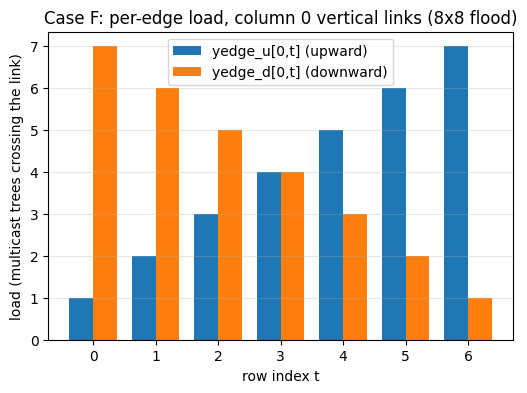

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.38
x = column0["t"]
ax.bar(x - width / 2, column0["yedge_u[0,t]"], width, label="yedge_u[0,t] (upward)", color="tab:blue")
ax.bar(x + width / 2, column0["yedge_d[0,t]"], width, label="yedge_d[0,t] (downward)", color="tab:orange")
ax.set_xlabel("row index t")
ax.set_ylabel("load (multicast trees crossing the link)")
ax.set_title("Case F: per-edge load, column 0 vertical links (8x8 flood)")
ax.set_xticks(list(x))
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.show()


## 4. Fulfilled vs. unfulfilled fills: the `_covered_fills` partition

Node 0 holds only `data[0]`; node 1 requests both `data[0]` and `data[1]`.
`data[1]` has no source anywhere, so `identify_mesh_casts` never emits an
entry for it -- `_covered_fills` reshapes the matched multicast networks back
into a `{ dst -> data }` map so `apply` can split `fills` into
`fulfilled_fill` / `unfulfilled_fill` by `intersect` / `subtract`, and `hops`
counts only the deliverable fill (`data[0]`), not the undeliverable one.
Before `81be62a4` this partition did not exist: every fill was reported
`fulfilled_fill` unconditionally, with `unfulfilled_fill` always empty
(`fills.map_.subtract(fills.map_)`).

**Code exercised**: `_covered_fills`
(`mesh_casts.py:114-137`, commit `81be62a4`, moved out of
`distributed_buffers.py` by the `/simplify` module split); the partition
usage itself is now the shared `MulticastModel.apply`
(`distributed_buffers.py:97-147`, commit `81be62a4`, folded from
`FullyConnectedMulticastModel.apply` and the other three models' identical
`apply` tails during the module split).


In [8]:
partition_tags = [SpatialTag(0, 0)]
occ_p = isl.Map.read_from_str(CTX, "{ noc[g] -> data[d] : g = 0 and d = 0 }")
fill_p = isl.Map.read_from_str(CTX, "{ noc[g] -> data[d] : g = 1 and (d = 0 or d = 1) }")
dist_fn_1d = isl.Map.read_from_str(
    CTX,
    "{ [noc[gd] -> noc[gs]] -> hops[gd - gs] : gd >= gs;"
    "  [noc[gd] -> noc[gs]] -> hops[gs - gd] : gd <  gs }",
)
info_p = FullyConnectedMulticastModel(dist_fn_1d).apply(
    0, Fill(partition_tags, fill_p), Occupancy(partition_tags, occ_p)
)

print("fulfilled_fill.map_  :", info_p.fulfilled_fill.map_)
print("unfulfilled_fill.map_:", info_p.unfulfilled_fill.map_)
print("hops                 :", _eval_const(info_p.hops))

fulfilled = info_p.fulfilled_fill.map_
unfulfilled = info_p.unfulfilled_fill.map_
assert fulfilled.intersect(unfulfilled).is_empty(), "fulfilled/unfulfilled overlap"
assert fulfilled.union(unfulfilled).is_equal(fill_p), "fulfilled + unfulfilled != fills"
assert _eval_const(info_p.hops) == 1, "hops must count only the deliverable fill"
print()
print("fulfilled_fill and unfulfilled_fill partition fills exactly;")
print("hops (1) counts only the deliverable data[0], not the undeliverable data[1].")


fulfilled_fill.map_  : { noc[g = 1] -> data[d = 0] }
unfulfilled_fill.map_: { noc[g = 1] -> data[d = 1] }
hops                 : 1

fulfilled_fill and unfulfilled_fill partition fills exactly;
hops (1) counts only the deliverable data[0], not the undeliverable data[1].


## 5. Tuple-name genericity: `_mesh_node_tuple`

`_directed_mesh_links` and `_spoke_loads` used to hardcode the node tuple name
`'noc'` into every ISL map string they built. `_mesh_node_tuple` instead reads
the name (and dimensionality) off the caller's maps, so any spacetime tuple
name works. Below, the identical Case B geometry from Section 3 is run twice
--- once with the node tuple named `noc[x, y]`, once `pe[x, y]` --- and gives
identical hops and bottleneck.

**Code exercised**: `_mesh_node_tuple`
(`mesh_casts.py:140-164`, commit `81be62a4`, moved out of
`distributed_buffers.py` by the `/simplify` module split); its caller
`XYRoutingMulticastModel._directed_mesh_links`
(`distributed_buffers.py:417-515`, commit `142722f5`, touched again in
`81be62a4`).


In [9]:
def xy_case_b(name: str) -> tuple[isl.Map, isl.Map, isl.Map]:
    """Case B geometry (source (1,0) -> (0,2),(2,2)) under an arbitrary node
    tuple `name`, to exercise `_mesh_node_tuple`'s generic name/dims lookup.
    """
    occ = isl.Map.read_from_str(
        CTX, f"{{ {name}[x, y] -> data[c] : c = 0 and x = 1 and y = 0 }}"
    )
    fill = isl.Map.read_from_str(
        CTX,
        f"{{ {name}[x, y] -> data[c] : c = 0 and "
        f"((x = 0 and y = 2) or (x = 2 and y = 2)) }}",
    )
    dist_fn = isl.Map.read_from_str(
        CTX,
        f"{{ [{name}[xd, yd] -> {name}[xs, ys]] -> hops[(xd - xs) + (yd - ys)] :"
        f"      xd >= xs and yd >= ys;"
        f"  [{name}[xd, yd] -> {name}[xs, ys]] -> hops[-(xd - xs) + -(yd - ys)] :"
        f"      xd < xs and yd < ys;"
        f"  [{name}[xd, yd] -> {name}[xs, ys]] -> hops[-(xd - xs) + (yd - ys)] :"
        f"      xd < xs and yd >= ys;"
        f"  [{name}[xd, yd] -> {name}[xs, ys]] -> hops[(xd - xs) + -(yd - ys)] :"
        f"      xd >= xs and yd < ys }}",
    )
    return occ, fill, dist_fn


results = {}
for name in ("noc", "pe"):
    occ_n, fill_n, dist_fn_n = xy_case_b(name)
    info_n = XYRoutingMulticastModel(dist_fn_n).apply(
        0, Fill(xy_tags, fill_n), Occupancy(xy_tags, occ_n)
    )
    results[name] = (_eval_const(info_n.hops), info_n.edge_pressure.bottleneck())
    print(f"{name}[x, y]: hops = {results[name][0]}, bottleneck = {results[name][1]}")

assert results["noc"] == results["pe"] == (6, 1), results
print()
print("Identical numbers under both tuple names -- _mesh_node_tuple reads the name/dims generically.")


noc[x, y]: hops = 6, bottleneck = 1
pe[x, y]: hops = 6, bottleneck = 1

Identical numbers under both tuple names -- _mesh_node_tuple reads the name/dims generically.


## 6. Review checklist

Which lines are new (and need a reviewer's attention) vs. which lines predate
this work, mapped by demo section. `HypercubeMulticastModel`,
`identify_mesh_casts`, and `calculate_extents_per_dim` are the pre-existing
baseline and are intentionally absent from this table (and from this notebook).

| Section | Function(s) exercised | File | Lines | Commit |
|---|---|---|---|---|
| 2. FC vs. star | `EdgePressure` (class, `total`, `bottleneck`, `eval_edge`) | `edge_pressure.py` | 21-133 | `142722f5` |
| 2. FC vs. star | `MulticastModel.apply` (shared `apply`, all four models) | `distributed_buffers.py` | 97-147 | `81be62a4` |
| 2. FC vs. star | `FullyConnectedMulticastModel._transfer_cost` / `_cost_fully_connected` | `distributed_buffers.py` | 265-284 | `81be62a4` |
| 2. FC vs. star | `StarMulticastModel` (class, `_spoke_loads`) | `distributed_buffers.py` | 523-599 | `142722f5` |
| 2. FC vs. star | `StarMulticastModel._transfer_cost` (hops/edge_pressure aggregation, feeds the shared `apply`) | `distributed_buffers.py` | 546-547 | `81be62a4` |
| 2. FC vs. star | `TransferInfo.edge_pressure` field | `spatial.py` | 66-72 | `81be62a4` |
| 3. XY routing | `MulticastModel.apply` (shared `apply`) | `distributed_buffers.py` | 97-147 | `81be62a4` |
| 3. XY routing | `XYRoutingMulticastModel._transfer_cost` | `distributed_buffers.py` | 414-415 | `81be62a4` |
| 3. XY routing | `XYRoutingMulticastModel._directed_mesh_links` | `distributed_buffers.py` | 417-515 | `142722f5` (+`81be62a4`) |
| 3. XY routing | `EdgePressure.bottleneck` / `EdgePressure.eval_edge` | `edge_pressure.py` | 89-133 | `142722f5` |
| 4. Partition | `_covered_fills` | `mesh_casts.py` | 114-137 | `81be62a4` |
| 4. Partition | `MulticastModel.apply` (partition usage, shared) | `distributed_buffers.py` | 97-147 | `81be62a4` |
| 5. Tuple genericity | `_mesh_node_tuple` | `mesh_casts.py` | 140-164 | `81be62a4` |
| 5. Tuple genericity | `XYRoutingMulticastModel._directed_mesh_links` (caller) | `distributed_buffers.py` | 417-515 | `142722f5` (+`81be62a4`) |
| (all sections) | `_eval_const`, `_const_pwq` (shared scalar-extraction helpers) | `edge_pressure.py` | 159-201 | `81be62a4` |
| 2, 3 | `_edge_pressure_from_links` | `edge_pressure.py` | 230-251 | `142722f5` |

Notes on mixed attribution: `XYRoutingMulticastModel.apply` and
`StarMulticastModel.apply` were first written in `de426ae0`/`142722f5` and had
their `hops`/`edge_pressure` derivation refactored to a single
`identify_mesh_casts` call in `81be62a4` (rows above cite `81be62a4` for that
reason). A later, behavior-preserving `/simplify` module split folded every
model's `apply` into one `MulticastModel.apply` (`distributed_buffers.py:
97-147`) and moved `EdgePressure`/`identify_mesh_casts` and their helpers into
`edge_pressure.py`/`mesh_casts.py` respectively; the table above cites that
current location rather than `apply` on each subclass, since the per-model
`apply` no longer exists post-split -- only each model's `_transfer_cost` (the
one-line cost-kernel hook `apply` now calls) and cost-specific helper remain
on the subclass. `FullyConnectedMulticastModel`'s cost kernel
(`_cost_fully_connected`) is unchanged since `de426ae0` and predates the
reviewed range; only its fulfilled/unfulfilled partition usage (now inside
the shared `MulticastModel.apply`) is new in `81be62a4`.
